# Gravitational Waveform Generation with phenomxpy
## Models covered: IMRPhenomTE, IMRPhenomTEHM, IMRPhenomTHM, IMRPhenomTPHM

This notebook demonstrates how to generate gravitational waveforms using the `phenomxpy` package.
For each model we show:
- Time-domain polarizations $h_+(t)$, $h_\times(t)$
- Frequency-domain polarizations $\tilde{h}_+(f)$, $\tilde{h}_\times(f)$
- Individual time-domain modes $h_{lm}(t)$

### Models overview
| Model | Eccentric | Precessing | Higher modes |
|---|---|---|---|
| IMRPhenomTE   | ✅ | ❌ | ❌ (22 only) |
| IMRPhenomTEHM | ✅ | ❌ | ✅ |
| IMRPhenomTHM  | ❌ | ❌ | ✅ |
| IMRPhenomTPHM | ❌ | ✅ | ✅ |

Note that when calling the IMRPhenomTHM with the eccentricity and mean anomaly arguments it will default to the IMRPhenomTEHM model.

### Relation between modes and polarizations
$$h_+ - i\, h_\times = \sum_{l,m} h_{lm}(t)\; {}_{-2}Y_{lm}(\iota,\, \varphi_\mathrm{ref})$$

---
## 0. Imports and helper functions

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

import lal
import lalsimulation as lalsim

import phenomxpy
from phenomxpy.phenomte.phenomte import IMRPhenomTE
from phenomxpy.phenomt.phenomt import IMRPhenomTHM as IMRPhenomTEHM
from phenomxpy.utils import SecondtoMass

%matplotlib inline

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper: generate TD polarizations via LALSimulation (used as reference)
# ─────────────────────────────────────────────────────────────────────────────
def lalsim_td_polarizations(params: dict, model, mode_array: list, prec_version: int = 102):
    """
    Generate time-domain polarizations using LALSimulation ChooseTDWaveform.

    Parameters
    ----------
    params : dict
        Must contain: m1, m2, s1, s2, dMpc, inclination, phi_ref,
        f_ref, f_min, delta_t, eccentricity, meanPerAno
    model : lalsim approximant integer
        e.g. lalsim.IMRPhenomTHM
    mode_array : list of [l, m]
        Modes to include, e.g. [[2,2],[2,-2],[3,3],...]
    prec_version : int
        PhenomXP precession version (default 102, NNLO angles)

    Returns
    -------
    times : np.ndarray   Time array [s]
    hp    : np.ndarray   Plus polarization
    hc    : np.ndarray   Cross polarization
    """
    lalparams = lal.CreateDict()
    ModeArray = lalsim.SimInspiralCreateModeArray()
    for l, m in mode_array:
        if m == 0:
            continue
        lalsim.SimInspiralModeArrayActivateMode(ModeArray, l, m)
    lalsim.SimInspiralWaveformParamsInsertModeArray(lalparams, ModeArray)
    lalsim.SimInspiralWaveformParamsInsertPhenomXPrecVersion(lalparams, prec_version)

    hp, hc = lalsim.SimInspiralChooseTDWaveform(
        lal.MSUN_SI * params["m1"],
        lal.MSUN_SI * params["m2"],
        *params["s1"],
        *params["s2"],
        params["dMpc"] * 1e6 * lal.PC_SI,
        params["inclination"],
        params["phi_ref"],
        0.0,  # longAscNodes
        params["eccentricity"],
        params["meanPerAno"],
        params["delta_t"],
        params["f_min"],
        params["f_ref"],
        lalparams,
        model,
    )
    times = np.arange(len(hp.data.data)) * params["delta_t"]
    return times, hp.data.data, hc.data.data

---
## 1. IMRPhenomTE and IMRPhenomTEHM

**IMRPhenomTE** models an eccentric, non-precessing binary with only the dominant $(2,\pm 2)$ mode.  
**IMRPhenomTEHM** extends this to include higher-order modes (HOM): $(2,\pm 1)$, $(3,\pm 3)$, $(4,\pm 4)$, $(5,\pm 5)$.

The two models share the same parameter interface; the difference is which class is instantiated.

### Binary configuration
| Parameter | Value |
|---|---|
| Mass ratio $q = m_1/m_2$ | 4 |
| Sym. mass ratio $\eta$ | 0.16 |
| $\chi_{1z}$ | 0.4 |
| $\chi_{2z}$ | 0.3 |
| Eccentricity $e$ | 0.1 |
| Mean anomaly $l$ | 1.2 rad |
| Total mass $M$ | 100 $M_\odot$ |
| Distance | 2000 Mpc |
| Inclination $\iota$ | 1.4 rad |
| $\varphi_\mathrm{ref}$ | 1.3 rad |

In [3]:
# ── Binary parameters ─────────────────────────────────────────────────────────
q_te = 4.0
eta_te = q_te / (1.0 + q_te) ** 2.0

params_te = {
    # ── Intrinsic ──────────────────────────────────────────────────────────────
    "eta": eta_te,
    "total_mass": 100.0,  # Total mass [M_sun]
    "s1": [0.0, 0.0, 0.4],  # Spin on body 1 (x, y, z components)
    "s2": [0.0, 0.0, 0.3],  # Spin on body 2 (x, y, z components)
    "eccentricity": 0.1,  # Orbital eccentricity at f_ref
    "mean_anomaly": 1.2,  # Mean anomaly at f_ref [rad]
    # ── Extrinsic ──────────────────────────────────────────────────────────────
    "distance": 2000.0,  # Luminosity distance [Mpc]
    "inclination": 1.4,  # Inclination angle [rad]
    "phi_ref": 1.3,  # Reference orbital phase [rad]
    # ── Sampling ───────────────────────────────────────────────────────────────
    "f_min": 10.0,  # Starting frequency [Hz]
    "f_ref": 10.0,  # Reference frequency [Hz]
    "delta_t": 1.0 / 4096.0,  # Time step [s]  →  f_samp = 4096 Hz
    # ── Mode content ───────────────────────────────────────────────────────────
    # IMRPhenomTE uses only (2,±2); IMRPhenomTEHM uses all modes listed here
    "mode_array": [[2, 2], [2, -2], [2, 1], [2, -1], [3, 3], [3, -3], [4, 4], [4, -4], [5, 5], [5, -5], [2, 0]],
    # ── Conditioning ───────────────────────────────────────────────────────────
    # condition=True tapers the waveform start; set False for a shorter inspiral
    "condition": True,
}

print(f"eta = {eta_te:.4f}   (q = {q_te})")
print(f"Total mass   = {params_te['total_mass']} M_sun")
print(f"Eccentricity = {params_te['eccentricity']},  mean anomaly = {params_te['mean_anomaly']} rad")

eta = 0.1600   (q = 4.0)
Total mass   = 100.0 M_sun
Eccentricity = 0.1,  mean anomaly = 1.2 rad


### 1a. Time-domain polarizations

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


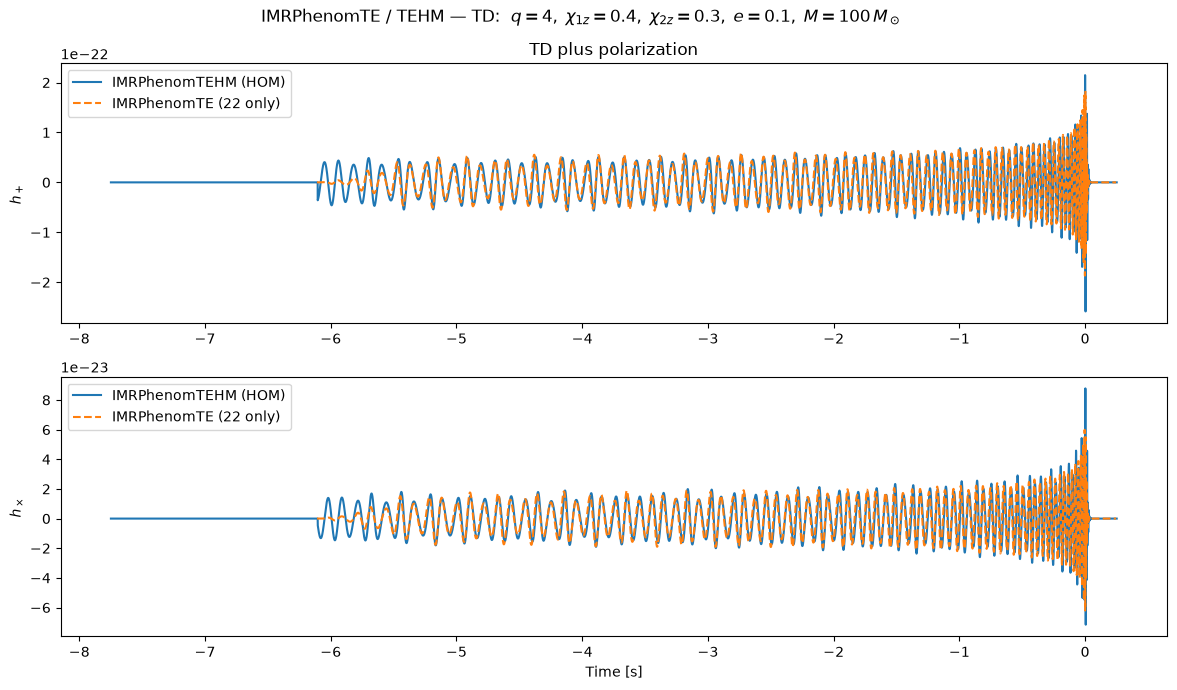

In [4]:
# ── Instantiate both models with identical parameters ─────────────────────────
phen_te = IMRPhenomTE(**params_te)  # dominant-mode only
phen_tehm = IMRPhenomTEHM(**params_te)  # higher-order modes

# ── Compute TD polarizations ──────────────────────────────────────────────────
# Returns: (h_plus, h_cross, times)
hp_te, hc_te, tt_te = phen_te.compute_polarizations()
hp_tehm, hc_tehm, tt_tehm = phen_tehm.compute_polarizations()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

axes[0].plot(tt_tehm, hp_tehm, lw=1.5, label="IMRPhenomTEHM (HOM)")
axes[0].plot(tt_te, hp_te, lw=1.5, ls="--", label="IMRPhenomTE (22 only)")
axes[0].set_ylabel(r"$h_+$")
axes[0].legend()
axes[0].set_title("TD plus polarization")

axes[1].plot(tt_tehm, hc_tehm, lw=1.5, label="IMRPhenomTEHM (HOM)")
axes[1].plot(tt_te, hc_te, lw=1.5, ls="--", label="IMRPhenomTE (22 only)")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("Time [s]")
axes[1].legend()

# NOTE: the long inspiral tail is due to condition=True, which tapers the
# waveform start smoothly. Set condition=False for a shorter inspiral.
fig.suptitle(r"IMRPhenomTE / TEHM — TD:  $q=4,\;\chi_{1z}=0.4,\;\chi_{2z}=0.3,\;e=0.1,\;M=100\,M_\odot$")
plt.tight_layout()
plt.show()

### 1b. Frequency-domain polarizations

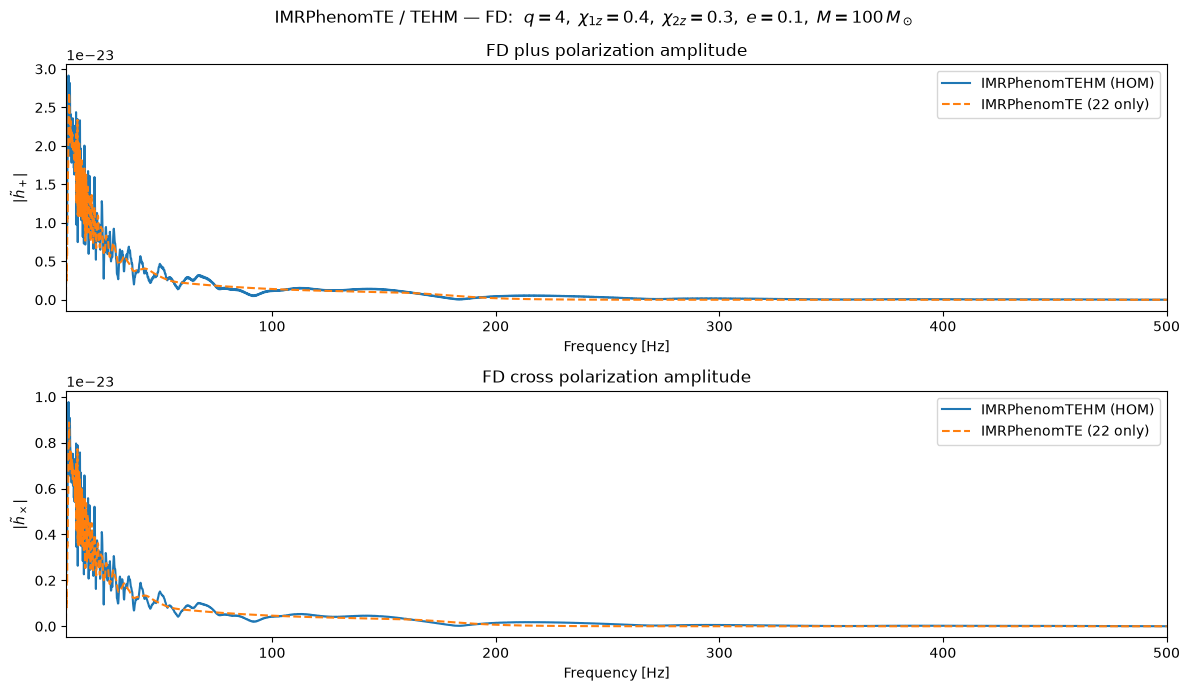

In [5]:
# ── Compute FD polarizations ──────────────────────────────────────────────────
# Returns: (h_plus, h_cross, freqs)
hp_te_fd, hc_te_fd, ff_te = phen_te.compute_fd_polarizations()
hp_tehm_fd, hc_tehm_fd, ff_tehm = phen_tehm.compute_fd_polarizations()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(ff_tehm, np.abs(hp_tehm_fd), lw=1.5, label="IMRPhenomTEHM (HOM)")
axes[0].plot(ff_te, np.abs(hp_te_fd), lw=1.5, ls="--", label="IMRPhenomTE (22 only)")
axes[0].set_xlim(8, 500)
axes[0].set_ylabel(r"$|\tilde{h}_+|$")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].legend()
axes[0].set_title("FD plus polarization amplitude")

axes[1].plot(ff_tehm, np.abs(hc_tehm_fd), lw=1.5, label="IMRPhenomTEHM (HOM)")
axes[1].plot(ff_te, np.abs(hc_te_fd), lw=1.5, ls="--", label="IMRPhenomTE (22 only)")
axes[1].set_xlim(8, 500)
axes[1].set_ylabel(r"$|\tilde{h}_\times|$")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].legend()
axes[1].set_title("FD cross polarization amplitude")

fig.suptitle(r"IMRPhenomTE / TEHM — FD:  $q=4,\;\chi_{1z}=0.4,\;\chi_{2z}=0.3,\;e=0.1,\;M=100\,M_\odot$")
plt.tight_layout()
plt.show()

### 1c. Time-domain modes $h_{lm}(t)$ — IMRPhenomTEHM

Individual modes are obtained via `compute_hlms()`, which returns a dictionary
`{(l, m): array}` and the corresponding time array.

In [6]:
phen_tehm

Available modes: ['22', '2-2', '21', '2-1', '33', '3-3', '44', '4-4', '55', '5-5', '20']


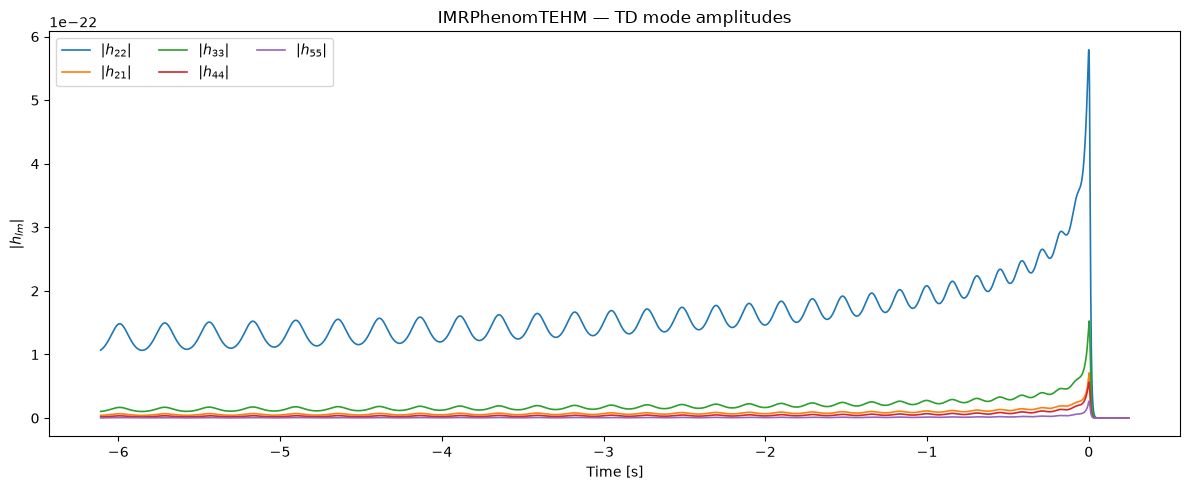

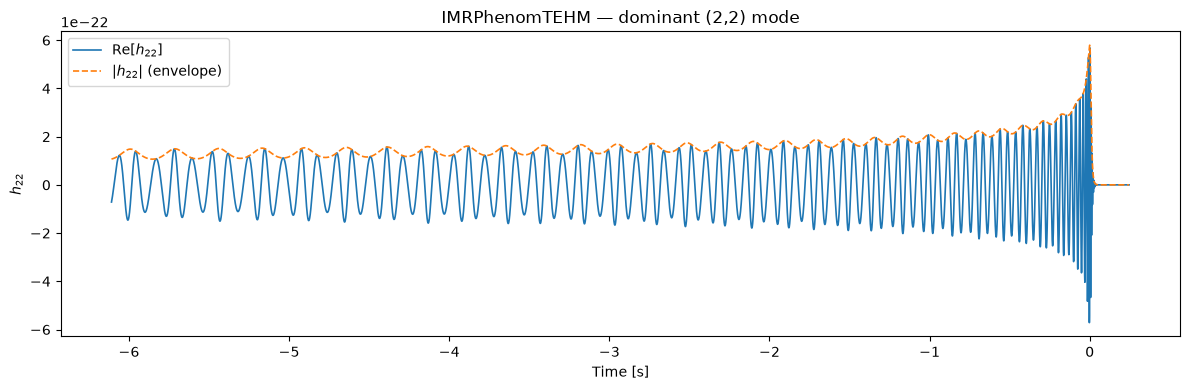

In [7]:
# ── Compute individual TD modes ───────────────────────────────────────────────
# Returns: dict {(l, m): complex array}, time array
hlms_tehm, tt_modes_tehm = phen_tehm.compute_hlms()

print("Available modes:", list(hlms_tehm.keys()))

# ── Plot amplitude of every mode (positive m only to avoid clutter) ───────────
fig, ax = plt.subplots(figsize=(12, 5))
for lm, hlm in hlms_tehm.items():
    l = lm[0]
    m = lm[1:]
    if int(m) > 0:
        ax.plot(tt_modes_tehm, np.abs(hlm), lw=1.2, label=rf"$|h_{{{l}{m}}}|$")
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"$|h_{lm}|$")
ax.set_title("IMRPhenomTEHM — TD mode amplitudes")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

# ── Dominant (2,2) mode: real part and envelope ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tt_modes_tehm, np.real(hlms_tehm["22"]), lw=1.2, label=r"$\mathrm{Re}[h_{22}]$")
ax.plot(tt_modes_tehm, np.abs(hlms_tehm["22"]), lw=1.2, ls="--", label=r"$|h_{22}|$ (envelope)")
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"$h_{22}$")
ax.set_title("IMRPhenomTEHM — dominant (2,2) mode")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. IMRPhenomTHM

**IMRPhenomTHM** is the non-eccentric ($e \to 0$), non-precessing counterpart of IMRPhenomTEHM.
It includes higher-order modes and is validated against the LALSimulation implementation.

### Binary configuration
| Parameter | Value |
|---|---|
| Mass ratio $q$ | 2.5 |
| $\chi_{1z}$ | 0.9 |
| $\chi_{2z}$ | 0.3 |
| Eccentricity | 0 (circular) |
| Total mass $M$ | 80 $M_\odot$ |
| Distance | 100 Mpc |

In [8]:
# ── Binary parameters ─────────────────────────────────────────────────────────
q_thm = 2.5
eta_thm = q_thm / (1.0 + q_thm) ** 2.0
m1_thm = q_thm / (1.0 + q_thm)  # dimensionless
m2_thm = 1.0 / (1.0 + q_thm)
M_thm = 80.0  # total mass [M_sun]
f_max = 2048.0
params_thm = {
    # ── Intrinsic ──────────────────────────────────────────────────────────────
    "m1": m1_thm * M_thm,
    "m2": m2_thm * M_thm,
    "total_mass": M_thm,
    "eta": eta_thm,
    "s1": [0.0, 0.0, 0.9],
    "s2": [0.0, 0.0, 0.3],
    "eccentricity": 0.0,  # circular orbit
    "meanPerAno": 0.0,
    # ── Extrinsic ──────────────────────────────────────────────────────────────
    "distance": 100.0,  # [Mpc]
    "dMpc": 100.0,
    "inclination": np.pi / 3.0,
    "phi_ref": 1.0,
    # ── Sampling ───────────────────────────────────────────────────────────────
    "f_min": 20.0,
    "f_ref": 20.0,
    "delta_t": 0.5 / f_max,
    "delta_f": 1.0 / 16.0,
    "f_max": f_max,
    # ── Mode content ───────────────────────────────────────────────────────────
    "mode_array": [[2, 2], [2, -2], [2, 1], [2, -1], [3, 3], [3, -3], [4, 4], [4, -4], [5, 5], [5, -5]],
    "condition": False,  # if performing a FT conditioning of the TD waveforms must be True
}

print(f"eta = {eta_thm:.4f}   (q = {q_thm})")
print(f"Total mass = {M_thm} M_sun,  chi1z = 0.9,  chi2z = 0.3,  e = 0 (circular)")

eta = 0.2041   (q = 2.5)
Total mass = 80.0 M_sun,  chi1z = 0.9,  chi2z = 0.3,  e = 0 (circular)


### 2a. Time-domain polarizations — comparison with LALSimulation

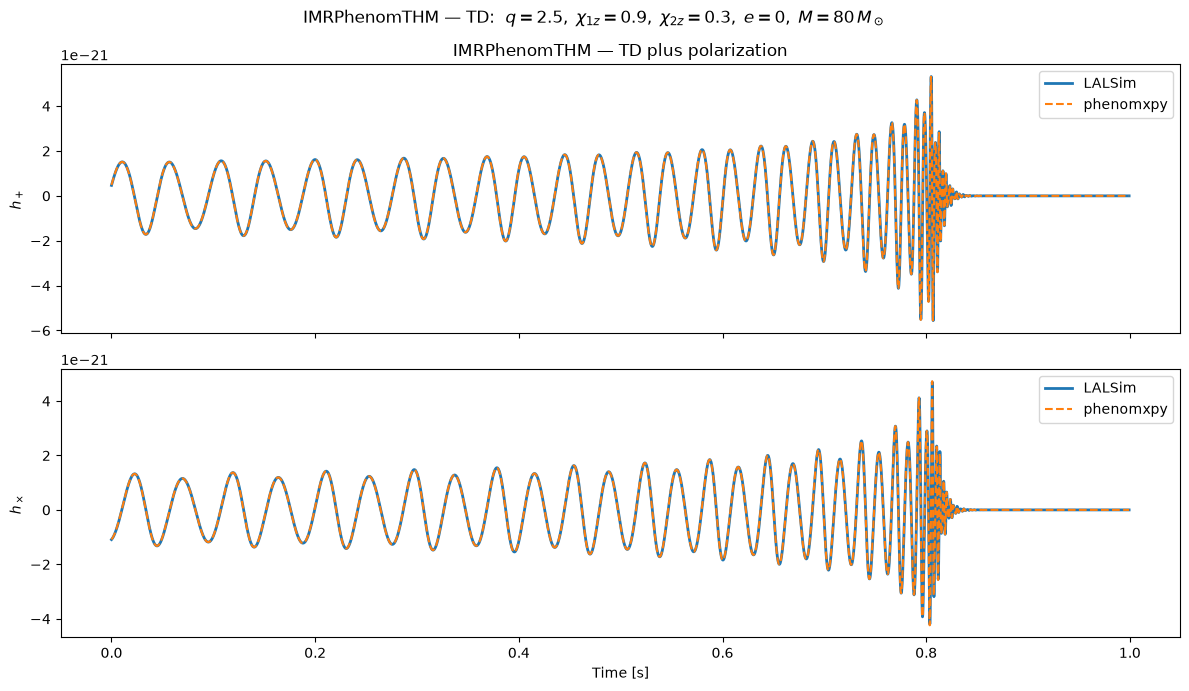

In [9]:
# ── phenomxpy ─────────────────────────────────────────────────────────────────
phen_thm = phenomxpy.IMRPhenomTHM(**params_thm)
hp_thm_td, hc_thm_td, tt_thm_td = phen_thm.compute_polarizations()

# ── LALSim reference ──────────────────────────────────────────────────────────
tt_lal_thm, hp_lal_thm, hc_lal_thm = lalsim_td_polarizations(
    params_thm,
    lalsim.IMRPhenomTHM,
    mode_array=params_thm["mode_array"],
)

# ── Plot (align both waveforms to t=0 for easy visual comparison) ─────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(tt_lal_thm - tt_lal_thm[0], hp_lal_thm, lw=2, label="LALSim")
axes[0].plot(tt_thm_td - tt_thm_td[0], hp_thm_td, lw=1.5, ls="--", label="phenomxpy")
axes[0].set_ylabel(r"$h_+$")
axes[0].legend()
axes[0].set_title("IMRPhenomTHM — TD plus polarization")

axes[1].plot(tt_lal_thm - tt_lal_thm[0], hc_lal_thm, lw=2, label="LALSim")
axes[1].plot(tt_thm_td - tt_thm_td[0], hc_thm_td, lw=1.5, ls="--", label="phenomxpy")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("Time [s]")
axes[1].legend()

fig.suptitle(r"IMRPhenomTHM — TD:  $q=2.5,\;\chi_{1z}=0.9,\;\chi_{2z}=0.3,\;e=0,\;M=80\,M_\odot$")
plt.tight_layout()
plt.show()

### 2b. Frequency-domain polarizations 

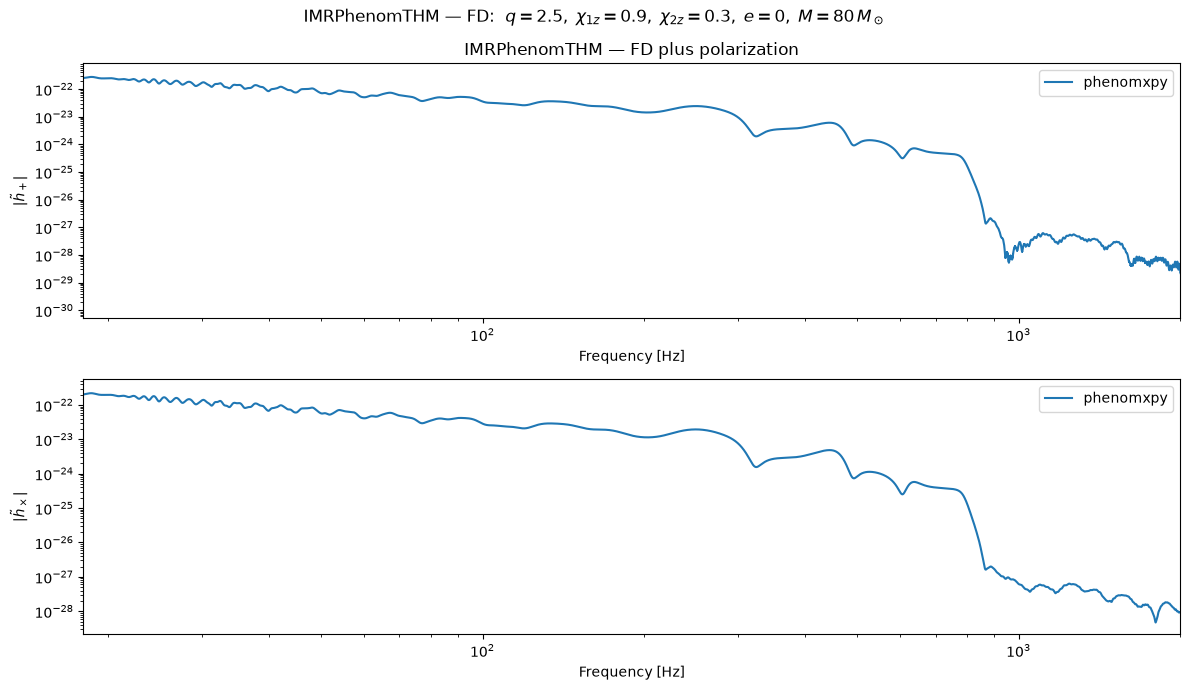

In [10]:
# Set condition=True in order to generate FD waveforms
params_thm["condition"] = True
phen_thm = phenomxpy.IMRPhenomTHM(**params_thm)
# ── phenomxpy FD ──────────────────────────────────────────────────────────────
hp_thm_fd, hc_thm_fd, ff_thm = phen_thm.compute_fd_polarizations()


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].loglog(ff_thm[1:], np.abs(hp_thm_fd[1:]), lw=1.5, ls="-", label="phenomxpy")
axes[0].set_xlim(18, 2000)
axes[0].set_ylabel(r"$|\tilde{h}_+|$")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].legend()
axes[0].set_title("IMRPhenomTHM — FD plus polarization")

axes[1].loglog(ff_thm[1:], np.abs(hc_thm_fd[1:]), lw=1.5, ls="-", label="phenomxpy")
axes[1].set_xlim(18, 2000)
axes[1].set_ylabel(r"$|\tilde{h}_\times|$")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].legend()

fig.suptitle(r"IMRPhenomTHM — FD:  $q=2.5,\;\chi_{1z}=0.9,\;\chi_{2z}=0.3,\;e=0,\;M=80\,M_\odot$")
plt.tight_layout()
plt.show()

### 2c. Time-domain modes $h_{lm}(t)$ — IMRPhenomTHM

Available modes: ['22', '2-2', '21', '2-1', '33', '3-3', '44', '4-4', '55', '5-5']


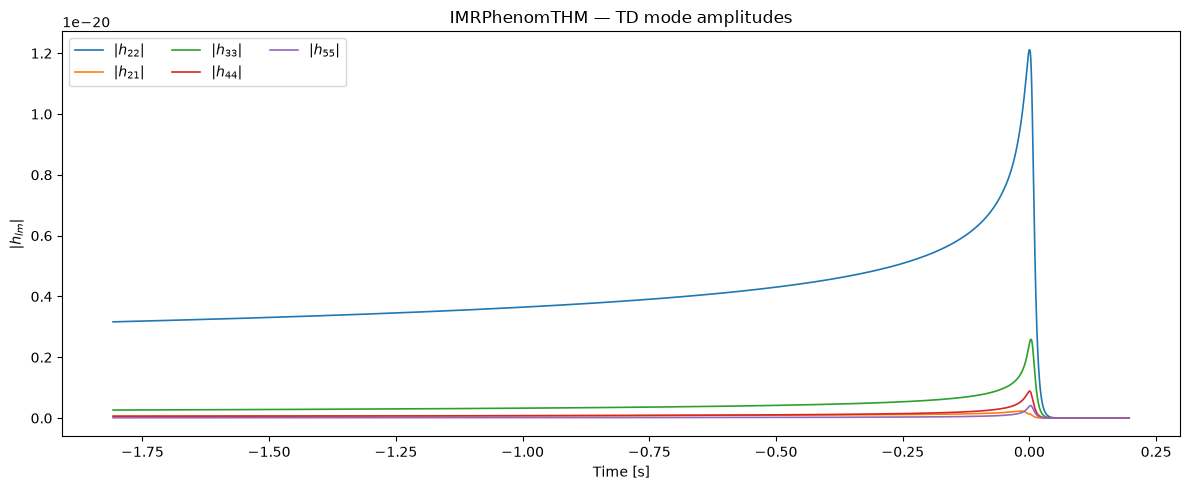

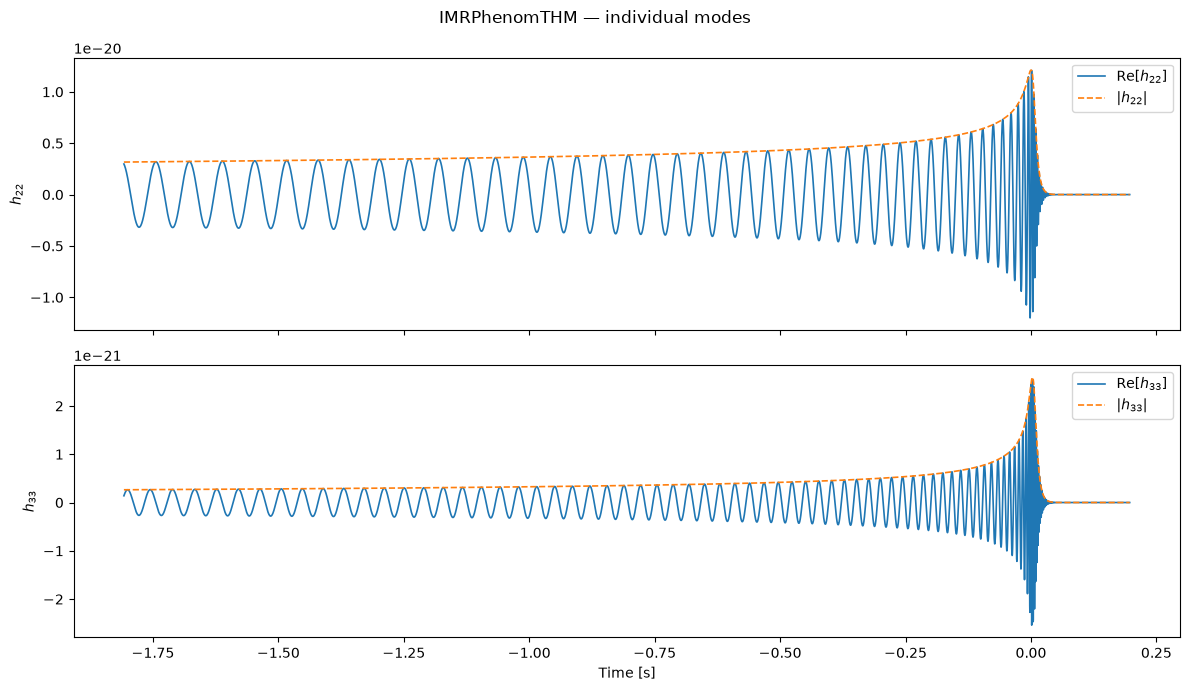

In [11]:
# ── Compute individual TD modes ───────────────────────────────────────────────
hlms_thm, tt_hlms_thm = phen_thm.compute_hlms()

print("Available modes:", list(hlms_thm.keys()))

# ── All mode amplitudes ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for lm, hlm in hlms_thm.items():
    l = lm[0]
    m = lm[1:]
    if int(m) > 0:
        ax.plot(tt_hlms_thm, np.abs(hlm), lw=1.2, label=rf"$|h_{{{l}{m}}}|$")
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"$|h_{lm}|$")
ax.set_title("IMRPhenomTHM — TD mode amplitudes")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

# ── Side-by-side: (2,2) and (3,3) modes ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, lm in zip(axes, ["22", "33"]):
    l = lm[0]
    m = lm[1:]
    ax.plot(tt_hlms_thm, np.real(hlms_thm[lm]), lw=1.2, label=rf"$\mathrm{{Re}}[h_{{{l}{m}}}]$")
    ax.plot(tt_hlms_thm, np.abs(hlms_thm[lm]), lw=1.2, ls="--", label=rf"$|h_{{{l}{m}}}|$")
    ax.set_ylabel(rf"$h_{{{l}{m}}}$")
    ax.legend()

axes[-1].set_xlabel("Time [s]")
fig.suptitle("IMRPhenomTHM — individual modes")
plt.tight_layout()
plt.show()

---
## 3. IMRPhenomTPHM

**IMRPhenomTPHM** models a **precessing** binary with higher-order modes.
Precession is described by NNLO (next-to-next-to-leading order) angles (version 102).

> ⚠️ The `eccentricity` and `meanPerAno` keys must **not** be passed to
> `IMRPhenomTPHM`; they are removed from the parameter dictionary below.

An in-plane spin component ($\chi_{1x} \neq 0$) on body 1 drives the precession
and populates all $m$ values in the co-precessing frame, including $m=0$.

### Binary configuration
| Parameter | Value |
|---|---|
| Mass ratio $q$ | 2.5 |
| $\chi_{1x}$ | 0.8  ← in-plane → precessing |
| $\chi_{1z}$ | 0.2 |
| $\chi_{2z}$ | 0.3 |
| Total mass $M$ | 80 $M_\odot$ |
| Distance | 100 Mpc |

In [12]:
# ── Binary parameters ─────────────────────────────────────────────────────────
q_tphm = 2.5
eta_tphm = q_tphm / (1.0 + q_tphm) ** 2.0
m1_tphm = q_tphm / (1.0 + q_tphm)
m2_tphm = 1.0 / (1.0 + q_tphm)
M_tphm = 80.0
f_max = 4096.0

params_tphm = {
    # ── Intrinsic ──────────────────────────────────────────────────────────────
    "m1": m1_tphm * M_tphm,
    "m2": m2_tphm * M_tphm,
    "total_mass": M_tphm,
    "eta": eta_tphm,
    "s1": [0.5, 0.0, 0.2],  # large in-plane component → strong precession
    "s2": [0.0, 0.0, 0.3],
    # ── Extrinsic ──────────────────────────────────────────────────────────────
    "distance": 100.0,
    "dMpc": 100.0,
    "inclination": np.pi / 3.0,
    "phi_ref": 1.0,
    # ── Sampling ───────────────────────────────────────────────────────────────
    "f_min": 20.0,
    "f_ref": 20.0,
    "delta_t": 0.5 / f_max,
    "f_max": f_max,
    # ── Mode content ───────────────────────────────────────────────────────────
    # (2,0) is included here: it is populated by precession
    "mode_array": [[2, 2], [2, -2], [2, 1], [2, -1], [2, 0], [3, 3], [3, -3], [4, 4], [4, -4], [5, 5], [5, -5]],
}

# LALSim also needs eccentricity/meanPerAno (set to zero for a circular orbit)
params_tphm_lal = deepcopy(params_tphm)
params_tphm_lal["eccentricity"] = 0.0
params_tphm_lal["meanPerAno"] = 0.0

print(f"eta = {eta_tphm:.4f}   (q = {q_tphm})")
print(f"Spin 1 = {params_tphm['s1']}  (precessing)")
print(f"Spin 2 = {params_tphm['s2']}")

eta = 0.2041   (q = 2.5)
Spin 1 = [0.5, 0.0, 0.2]  (precessing)
Spin 2 = [0.0, 0.0, 0.3]


### 3a. Time-domain polarizations — comparison with LALSimulation

Ignoring unknown fields: {'m2', 'dMpc', 'm1'}


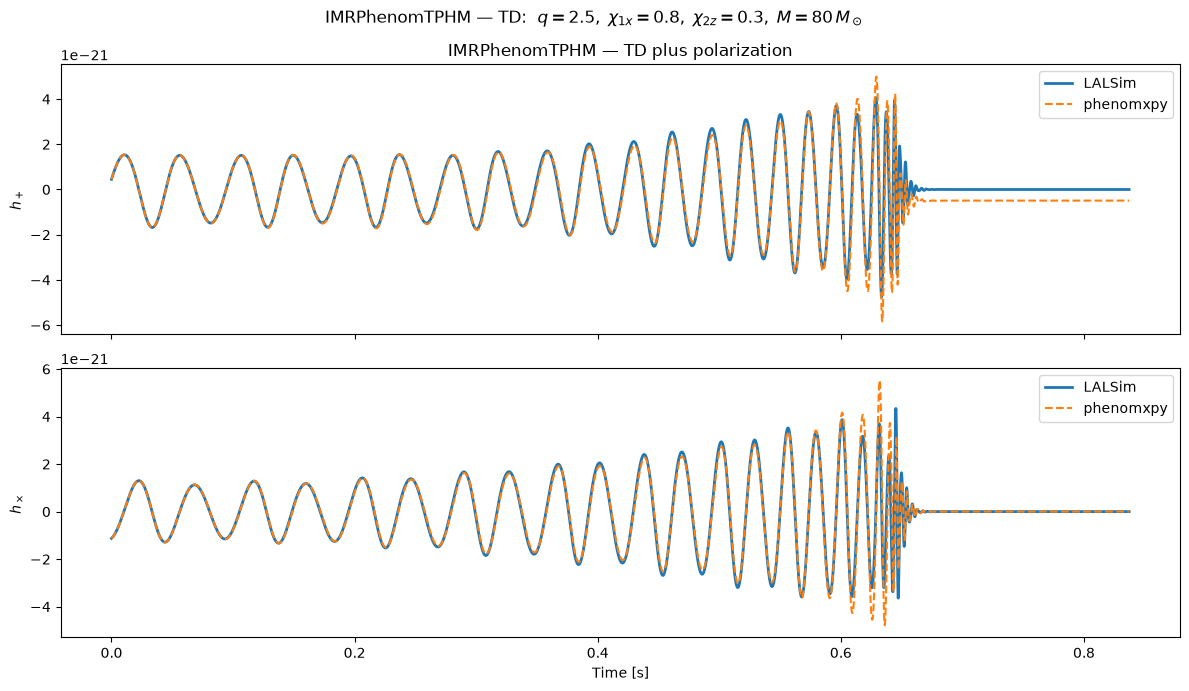

In [13]:
# ── phenomxpy ─────────────────────────────────────────────────────────────────
# Note: eccentricity / meanPerAno are NOT passed to IMRPhenomTPHM
phen_tphm = phenomxpy.IMRPhenomTPHM(**params_tphm)
hp_tphm_td, hc_tphm_td, tt_tphm_td = phen_tphm.compute_polarizations()

# ── LALSim reference (prec_version=102 → NNLO angles) ────────────────────────
tt_lal_tphm, hp_lal_tphm, hc_lal_tphm = lalsim_td_polarizations(
    params_tphm_lal,
    lalsim.IMRPhenomTPHM,
    mode_array=params_tphm["mode_array"],
    # prec_version=102,
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(tt_lal_tphm - tt_lal_tphm[0], hp_lal_tphm, lw=2, label="LALSim")
axes[0].plot(tt_tphm_td - tt_tphm_td[0], hp_tphm_td, lw=1.5, ls="--", label="phenomxpy")
axes[0].set_ylabel(r"$h_+$")
axes[0].legend()
axes[0].set_title("IMRPhenomTPHM — TD plus polarization")

axes[1].plot(tt_lal_tphm - tt_lal_tphm[0], hc_lal_tphm, lw=2, label="LALSim")
axes[1].plot(tt_tphm_td - tt_tphm_td[0], hc_tphm_td, lw=1.5, ls="--", label="phenomxpy")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("Time [s]")
axes[1].legend()

fig.suptitle(r"IMRPhenomTPHM — TD:  $q=2.5,\;\chi_{1x}=0.8,\;\chi_{2z}=0.3,\;M=80\,M_\odot$")
plt.tight_layout()
plt.show()

### 3b. Frequency-domain polarizations

Ignoring unknown fields: {'m2', 'dMpc', 'm1'}


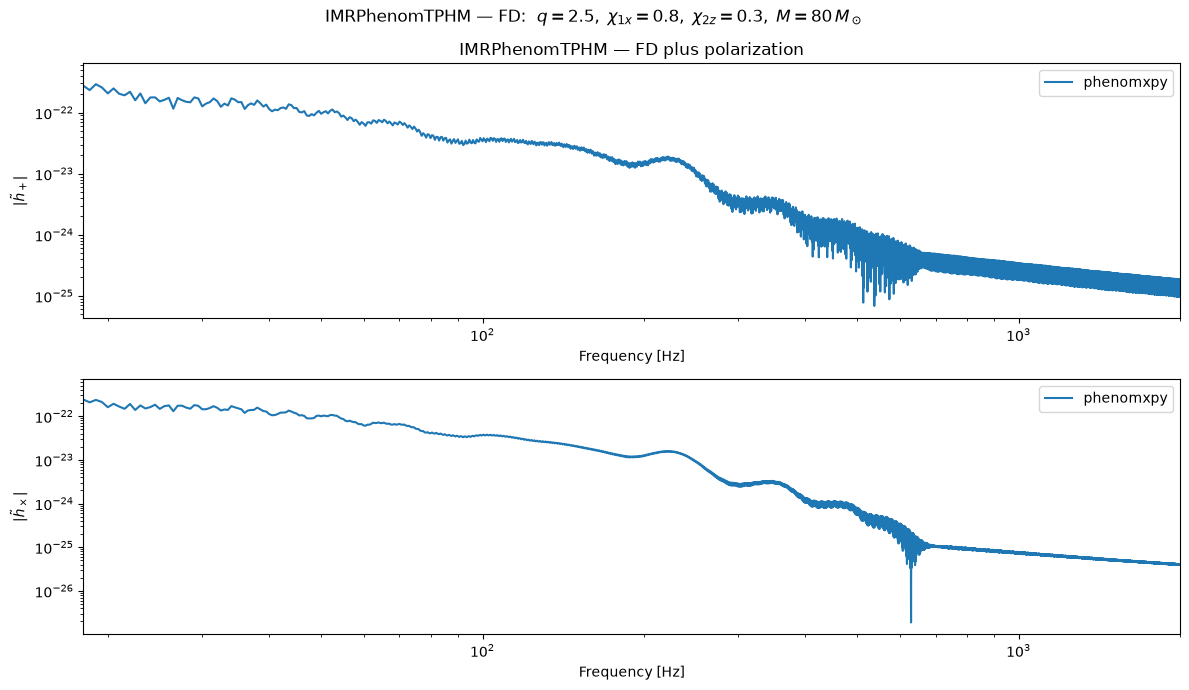

In [14]:
params_tphm["condition"] = True
phen_tphm = phenomxpy.IMRPhenomTPHM(**params_tphm)

# ── phenomxpy FD ──────────────────────────────────────────────────────────────
hp_tphm_fd, hc_tphm_fd, ff_tphm = phen_tphm.compute_fd_polarizations()


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].loglog(ff_tphm[1:], np.abs(hp_tphm_fd[1:]), lw=1.5, ls="-", label="phenomxpy")
axes[0].set_xlim(18, 2000)
axes[0].set_ylabel(r"$|\tilde{h}_+|$")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].legend()
axes[0].set_title("IMRPhenomTPHM — FD plus polarization")

axes[1].loglog(ff_tphm[1:], np.abs(hc_tphm_fd[1:]), lw=1.5, ls="-", label="phenomxpy")
axes[1].set_xlim(18, 2000)
axes[1].set_ylabel(r"$|\tilde{h}_\times|$")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].legend()

fig.suptitle(r"IMRPhenomTPHM — FD:  $q=2.5,\;\chi_{1x}=0.8,\;\chi_{2z}=0.3,\;M=80\,M_\odot$")
plt.tight_layout()
plt.show()

### 3c. Time-domain modes $h_{lm}(t)$ — IMRPhenomTPHM

For a precessing waveform the modes in the inertial J-frame include all $m$ values.
In particular, the $(2,0)$ mode is populated by precession even though it vanishes
for a non-precessing system.

Available modes: ['22', '2-2', '21', '2-1', '20', '33', '3-3', '44', '4-4', '55', '5-5']


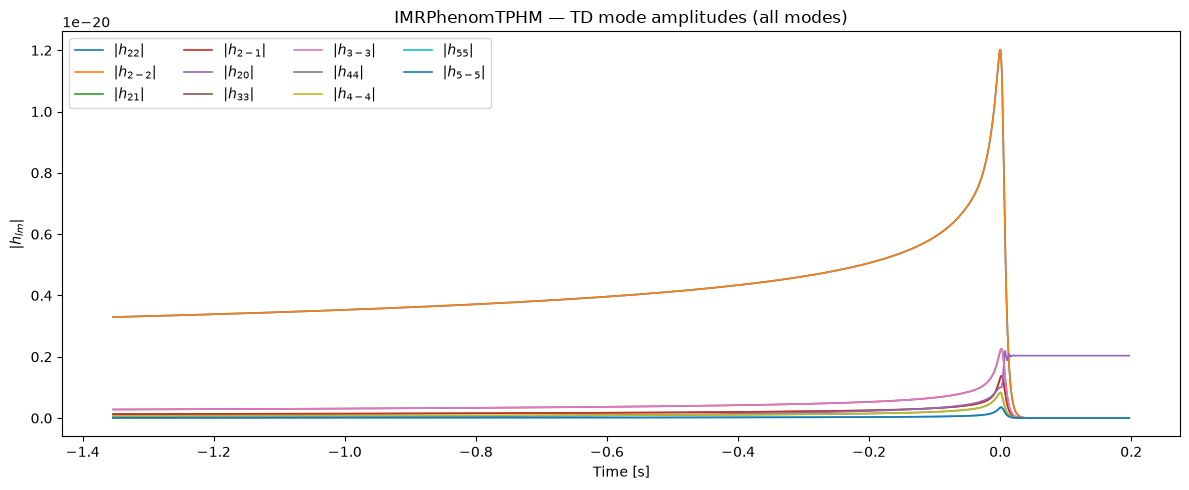

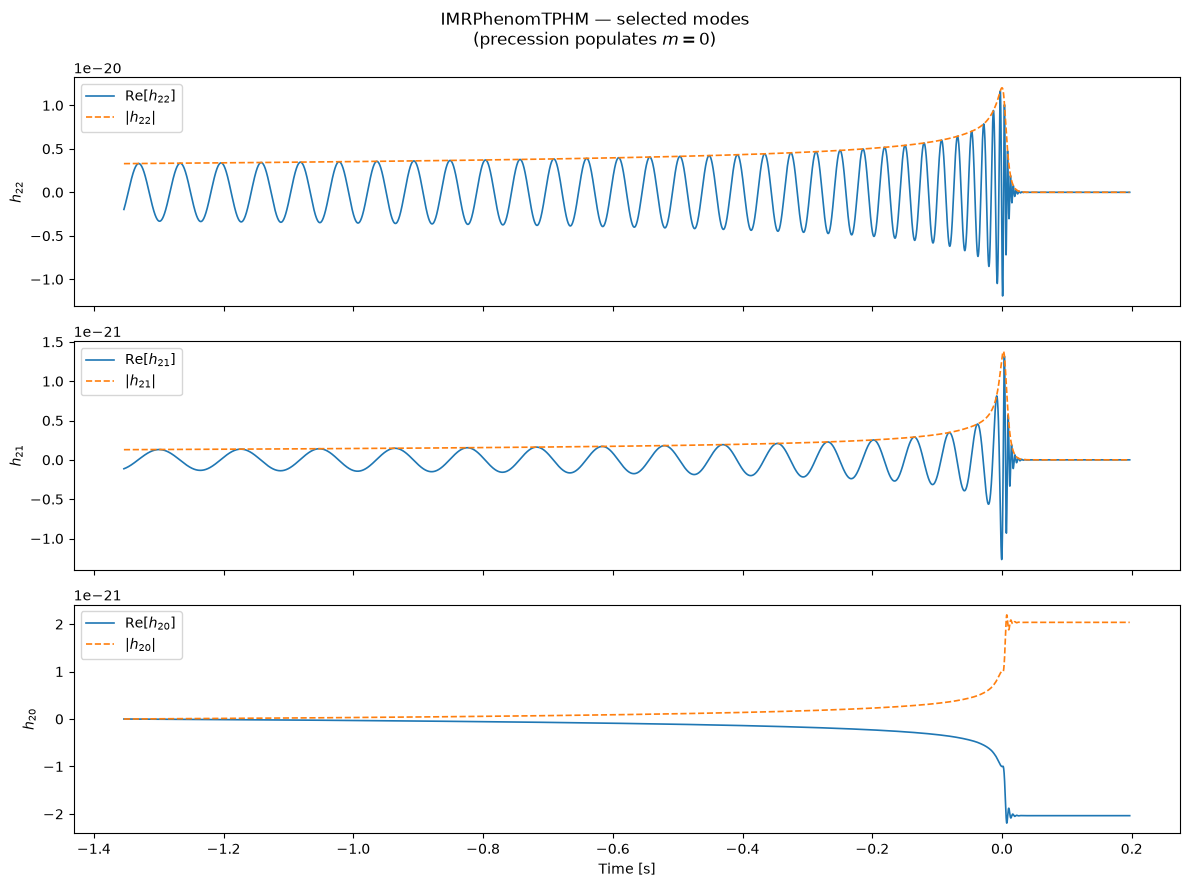

In [15]:
# ── Compute individual TD modes in the co-precessing frame ───────────────────────────────────────────────
hlms_tphm, tt_hlms_tphm = phen_tphm.compute_CPmodes()

print("Available modes:", list(hlms_tphm.keys()))

# ── All mode amplitudes ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for lm, hlm in hlms_tphm.items():
    l = lm[0]
    m = lm[1:]
    ax.plot(tt_hlms_tphm, np.abs(hlm), lw=1.2, label=rf"$|h_{{{l}{m}}}|$")
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"$|h_{lm}|$")
ax.set_title("IMRPhenomTPHM — TD mode amplitudes (all modes)")
ax.legend(ncol=4)
plt.tight_layout()
plt.show()

# ── (2,2), (2,1), (2,0): precession populates m=0 ────────────────────────────
modes_to_plot = [(2, 2), (2, 1), (2, 0)]
fig, axes = plt.subplots(len(modes_to_plot), 1, figsize=(12, 9), sharex=True)

for ax, (l, m) in zip(axes, modes_to_plot):
    lm_str = f"{l}{m}"
    hlm = hlms_tphm[lm_str]
    if hlm is not None:
        ax.plot(tt_hlms_tphm, np.real(hlm), lw=1.2, label=rf"$\mathrm{{Re}}[h_{{{l}{m}}}]$")
        ax.plot(tt_hlms_tphm, np.abs(hlm), lw=1.2, ls="--", label=rf"$|h_{{{l}{m}}}|$")
    ax.set_ylabel(rf"$h_{{{l}{m}}}$")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Time [s]")
fig.suptitle("IMRPhenomTPHM — selected modes\n(precession populates $m=0$)")
plt.tight_layout()
plt.show()

---
## Summary

| Model | Eccentric | Precessing | Higher modes |
|---|---|---|---|
| IMRPhenomTE   | ✅ | ❌ | ❌ (22 only) |
| IMRPhenomTEHM | ✅ | ❌ | ✅ |
| IMRPhenomTHM  | ❌ | ❌ | ✅ |
| IMRPhenomTPHM | ❌ | ✅ | ✅ |

### Key API

```python
# Instantiate
model = phenomxpy.IMRPhenomTHM(**params)

# Time-domain polarizations
hp, hc, times = model.compute_polarizations()

# Frequency-domain polarizations
hp_fd, hc_fd, freqs = model.compute_fd_polarizations()

# Individual TD modes  →  dict {(l, m): complex array}
hlms, times = model.compute_hlms()
```